# **RANDOM FOREST MODEL**

In [1]:
import os
import joblib

import pandas as pd
import numpy as np
import contextlib

import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

## **LOAD DATA & LABEL ENCODER**

In [2]:
# Load processed data
train_data = pd.read_csv('../../data/processed/train_data.csv')
test_data  = pd.read_csv('../../data/processed/test_data.csv')

X_train = train_data.drop('label_encoded', axis=1)
y_train = train_data['label_encoded']

X_test = test_data.drop('label_encoded', axis=1)
y_test = test_data['label_encoded']

# Load LabelEncoder
label_encoder = joblib.load('../../models/label_encoder.pkl')
label_names   = label_encoder.classes_

print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"Total kelas : {len(label_names)} tanaman")

Train shape : (1760, 26)
Test shape  : (440, 26)
Total kelas : 22 tanaman


In [3]:
label_names

array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)

## **Baseline Random Forest**

In [ ]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Melatih baseline model: \n")
rf_baseline.fit(X_train, y_train)

y_pred_baseline = rf_baseline.predict(X_test)
acc_baseline    = accuracy_score(y_test, y_pred_baseline)

stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores        = []

for train_idx, val_idx in tqdm.tqdm(stratified_kfold.split(X_train, y_train), total=5, desc="Cross-validation (5-fold)"):
    rf_fold_model = clone(rf_baseline)
    rf_fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    fold_score = rf_fold_model.score(X_train.iloc[val_idx], y_train.iloc[val_idx])
    cv_scores.append(fold_score)

cv_scores = np.array(cv_scores)

print(f"Baseline Accuracy (test set)   : {acc_baseline:.4f} ({acc_baseline*100:.2f}%)")
print(f"Cross-Val Accuracy (5-fold)    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Melatih baseline model: 



Cross-validation (5-fold): 100%|██████████| 5/5 [00:00<00:00,  5.88it/s]

Baseline Accuracy (test set)   : 0.9932 (99.32%)
Cross-Val Accuracy (5-fold)    : 0.9926 ± 0.0058


## **Hyperparameter Tuning: RandomizedSearchCV**

In [5]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

In [ ]:
param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 10, 20, 30, 50],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'bootstrap'         : [True, False],
}

rf_search = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 50,
    cv                  = 5,
    scoring             = 'accuracy',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 0,
)

total_fits = rf_search.n_iter * rf_search.cv  # 50 iter × 5 fold = 250 fit
with tqdm_joblib(tqdm.tqdm(total=total_fits, desc="RandomizedSearchCV")):
    rf_search.fit(X_train, y_train)

print("Best Parameters :")
for k, v in rf_search.best_params_.items():
    print(f"  {k:<22}: {v}")
print(f"\nBest CV Accuracy  : {rf_search.best_score_:.4f} ({rf_search.best_score_*100:.2f}%)")

RandomizedSearchCV: 750it [01:07, 11.15it/s]                         

Best Parameters :
  n_estimators          : 500
  min_samples_split     : 5
  min_samples_leaf      : 2
  max_features          : sqrt
  max_depth             : 50
  bootstrap             : False

Best CV Accuracy  : 0.9955 (99.55%)


## **Evaluasi Model Terbaik**

In [7]:
best_rf = rf_search.best_estimator_

y_pred        = best_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy (best model) : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

Test Accuracy (best model) : 0.9932 (99.32%)

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange

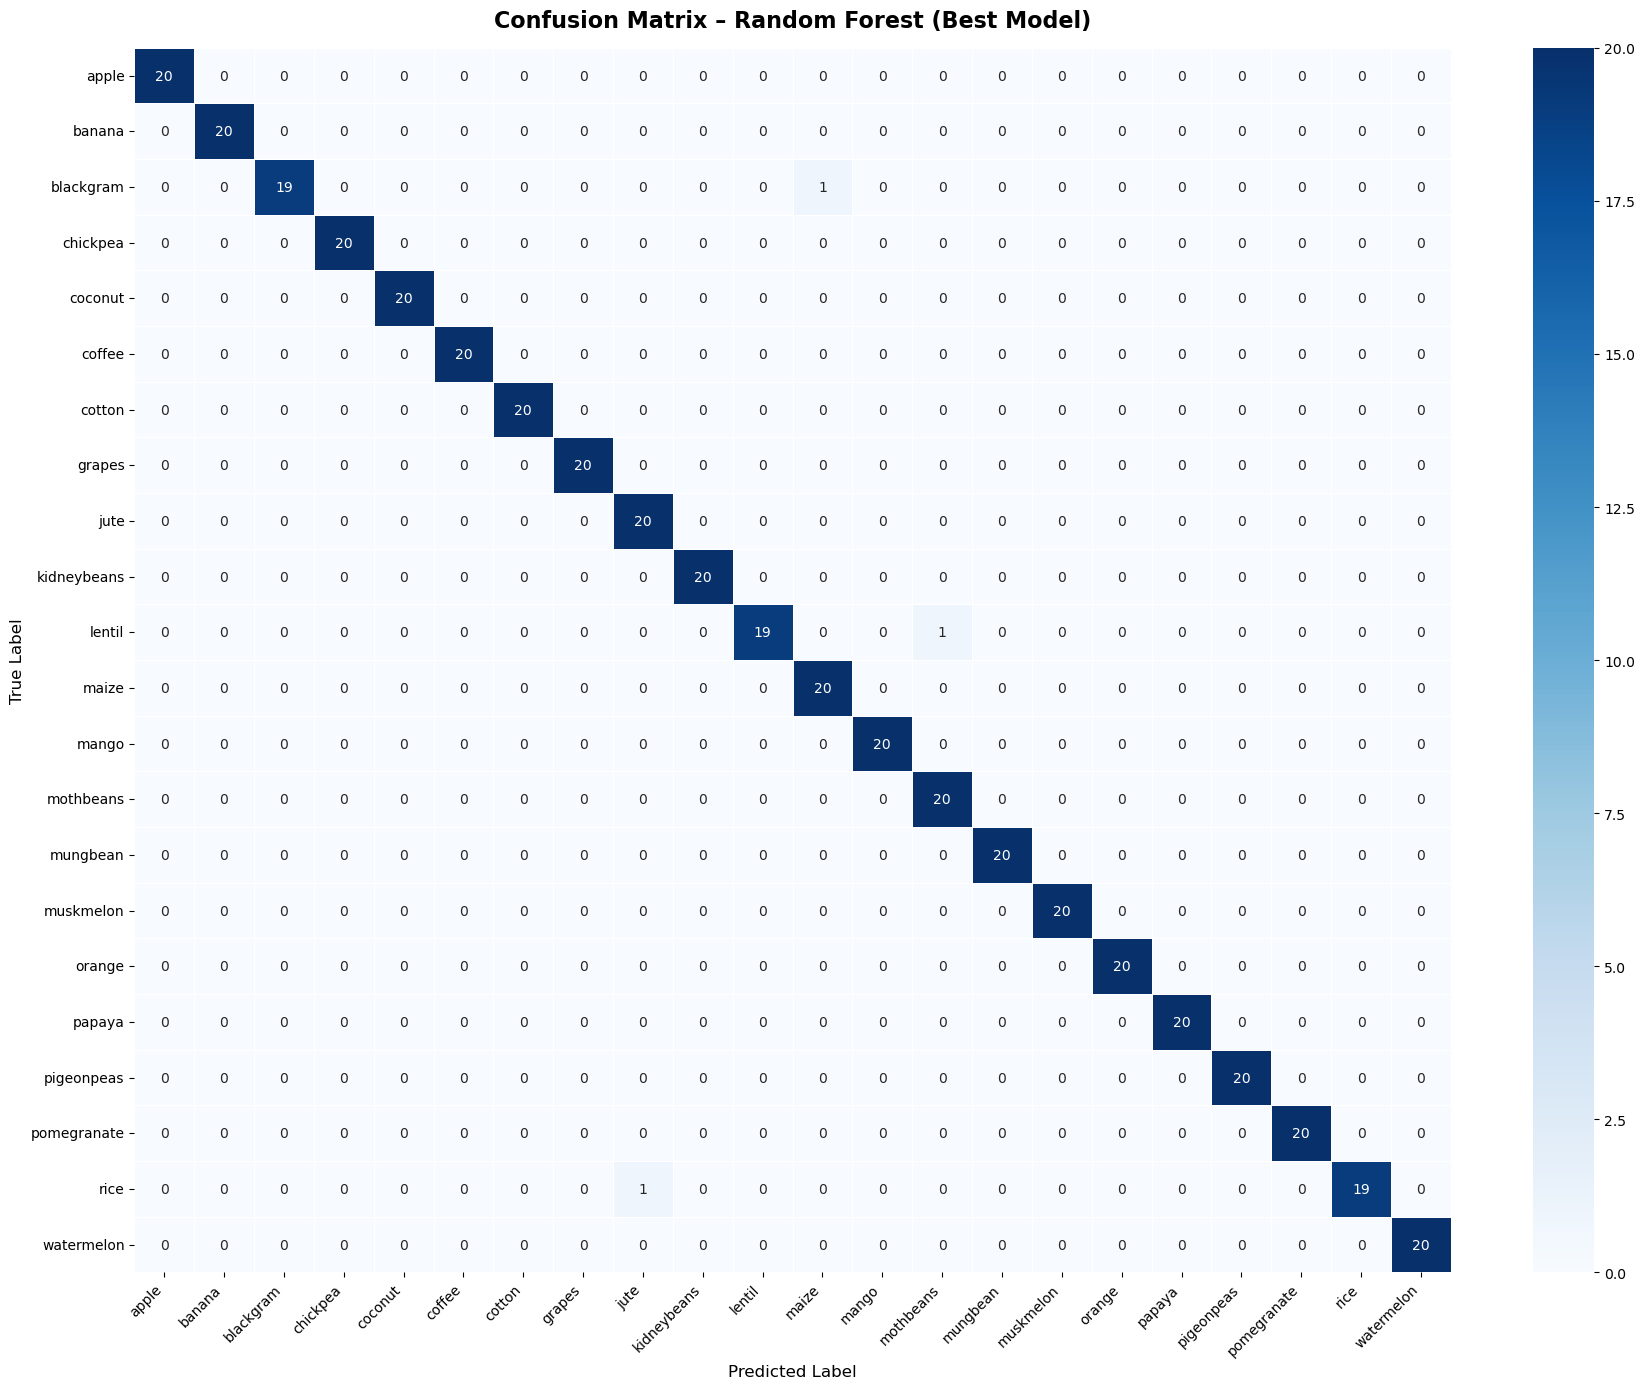

In [8]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 14))
sns.heatmap(
    conf_matrix,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    linewidths=0.5,
)
plt.title('Confusion Matrix – Random Forest (Best Model)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

## **Feature Importance**

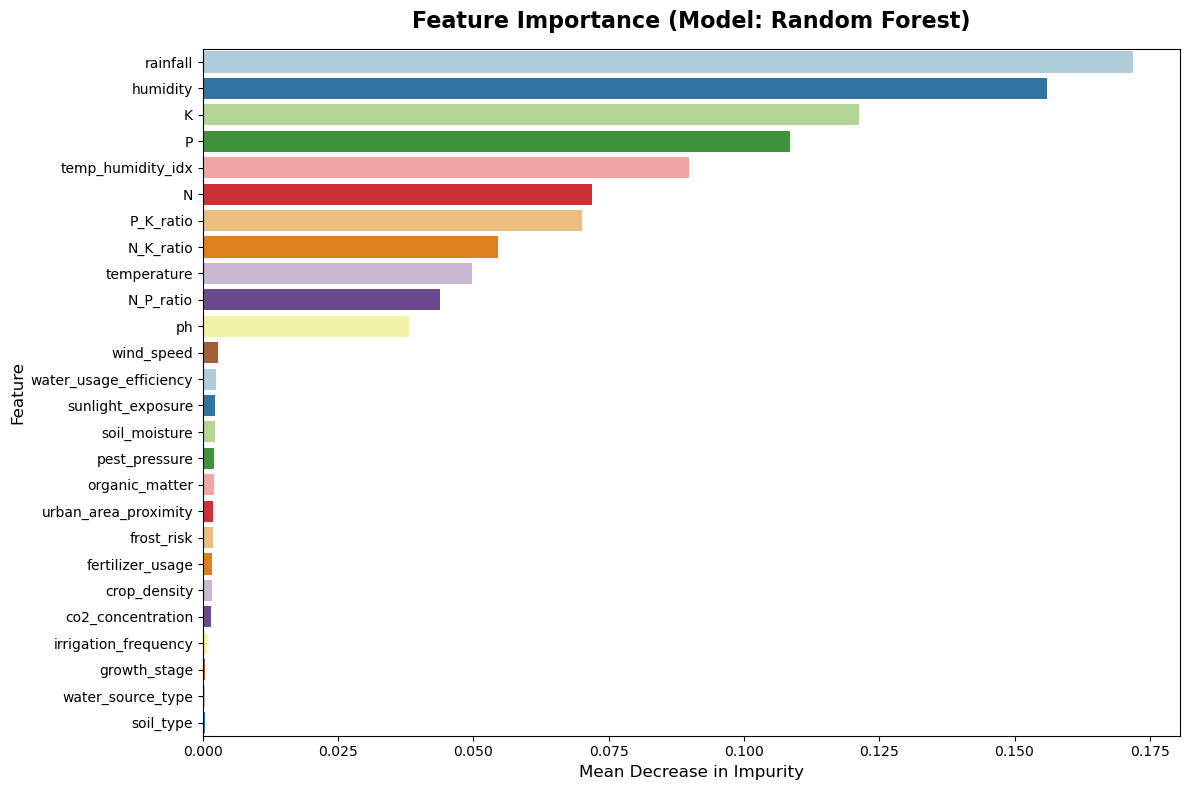


Top 10 fitur paling penting:
          feature  importance
         rainfall    0.171982
         humidity    0.155972
                K    0.121265
                P    0.108450
temp_humidity_idx    0.089822
                N    0.071851
        P_K_ratio    0.069992
        N_K_ratio    0.054613
      temperature    0.049800
        N_P_ratio    0.043784


In [9]:
feature_importances   = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': feature_importances,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='Paired', hue='feature', legend=False)
plt.title('Feature Importance (Model: Random Forest)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mean Decrease in Impurity', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 fitur paling penting:")
print(feature_importance_df.head(10).to_string(index=False))

## **Simpan Model**

In [12]:
model_dir     = '../../models'
rf_model_path = os.path.join(model_dir, 'random_forest_best.pkl')

os.makedirs(model_dir, exist_ok=True)
joblib.dump(best_rf,       rf_model_path)

print("Model tersimpan di:")
print(f"{os.path.abspath(rf_model_path)}")

# sample prediksi model
test_sample             = X_test.iloc[[7]]
predicted_label_encoded = best_rf.predict(test_sample)[0]
predicted_probabilities = best_rf.predict_proba(test_sample)[0]

top3_idx          = np.argsort(predicted_probabilities)[::-1][:3]
top3_crop_predictions = [(label_names[i], predicted_probabilities[i]) for i in top3_idx]

print(f"\nContoh prediksi:")
print(f"  Label asli   : {label_names[y_test.iloc[7]]}")
print(f"  Prediksi     : {label_names[predicted_label_encoded]}")
print("  Top-3 probabilitas:")
for crop, prob in top3_crop_predictions:
    print(f"    {crop:<15}: {prob*100:.2f}%")

Model tersimpan di:
/Users/faqihfirmanpratama/Documents/Ilmu Komputer/Semester 6/Daming/Project/models/random_forest_best.pkl

Contoh prediksi:
  Label asli   : blackgram
  Prediksi     : blackgram
  Top-3 probabilitas:
    blackgram      : 88.47%
    lentil         : 7.68%
    pigeonpeas     : 1.93%
